# University Library Resource Usage

## Overview

This notebook demonstrates the final reporting stage of a custom ETL pipeline built to transform one year of EZProxy web logs into an assessment-ready dataset. The original logs contained session identifiers, IP addresses, institutional network metadata, and resource URLs. Through a series of transformations, enrichment steps, and anonymization procedures, the data was converted into a privacy-preserving analytical dataset suitable for public analysis.

## Data Preparation

### Import Software Libraries and Dataset

In [6]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [7]:
df = pd.read_csv('ezproxy.csv')

### Brief Overview of the Dataset

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 542378 entries, 0 to 542377
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Unnamed: 0    542378 non-null  int64  
 1   id            542378 non-null  int64  
 2   session_id    542378 non-null  object 
 3   remote_ip     542378 non-null  object 
 4   session       542378 non-null  object 
 5   sha_username  542378 non-null  object 
 6   start         542378 non-null  object 
 7   end           542378 non-null  object 
 8   minutes       542378 non-null  float64
 9   affiliation   542378 non-null  object 
 10  role          542378 non-null  object 
 11  host          542378 non-null  object 
 12  host_name     526541 non-null  object 
 13  building      542378 non-null  object 
 14  month         542378 non-null  object 
 15  day           542378 non-null  object 
 16  hour          542378 non-null  int64  
dtypes: float64(1), int64(3), object(13)
memory usage

### Transform Time Columns

Time data in the `start` and `end` columns imports from the csv file as plain text. Transform those columns into Pandas `datetime` objects in the dataframe.

In [12]:
df["start"] = pd.to_datetime(df["start"])
df["end"] = pd.to_datetime(df["end"])

### EZProxy Session

An EZProxy session represents a continuous period of authenticated or tracked user activity while accessing licensed online library resources through the institution’s proxy service.

A session begins when a user successfully connects to EZProxy—either through authentication (off-campus or credentialed access) or through recognized institutional network access—and ends when the system determines the session has expired due to inactivity, logout, or timeout.

During this interval, the user may interact with one or more external scholarly or vendor-hosted systems (e.g., journal platforms, databases, eBook providers, etc.) These interactions are recorded as resource access events within the same session context.

For analyses that do not require resource-level detail from the `host` or `host_name` columns, multiple resource interactions within a session are collapsed into a _single row_ in the `session_metrics` dataframe.

Two analytical levels are used in this dashboard:

1. Event-level analysis (`df`)
   - One row per session-resource interaction
   - Used for resource usage analysis
2. Session-level analysis (`session_metrics`)
   - One row per `session_id`
   - Used for time and user metrics

In [15]:
session_metrics = df.drop_duplicates("session_id").copy()

In [16]:
session_metrics.shape

(261617, 17)

---

## Analytical Dashboard

### Key Metrics

In [20]:
sessions_internal = session_metrics.loc[session_metrics['sha_username']=='auto']['session_id'].count()
sessions_external = session_metrics.loc[session_metrics['sha_username']!='auto']['session_id'].count()
sessions_total = session_metrics['session_id'].count()

print("Time Period:", session_metrics["start"].min().date(), "to", session_metrics["end"].max().date())
print("Sessions:", session_metrics["session_id"].nunique())
print("% Internal vs External:", round(sessions_internal/sessions_total, 2)*100, "/", round(sessions_external/sessions_total, 2)*100)
print("Average Session Length:", round(session_metrics['minutes'].mean(), 1))
print("Unique Users:", session_metrics.loc[session_metrics["sha_username"] != "auto", "sha_username"].nunique())
print("Resources:", df.loc[df['host'] != 'INSTITUTIONAL_DOMAIN', "host"].nunique())
print("Buildings:", session_metrics["building"].nunique())
print("Total Usage Hours:", round(session_metrics["minutes"].sum() / 60, 0))

Time Period: 2015-01-01 to 2015-12-31
Sessions: 261617
% Internal vs External: 61.0 / 39.0
Average Session Length: 25.0
Unique Users: 3683
Resources: 1152
Buildings: 35
Total Usage Hours: 109118.0


---

### Resource Usage

> What resources are used most?

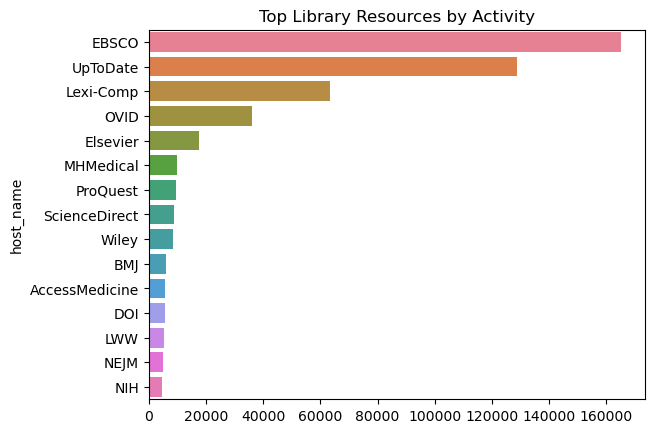

In [24]:
top_resources = (
    df["host_name"]
      .value_counts()
      .head(15)
      .sort_values(ascending=False)
)

sns.barplot(
    x=top_resources.values,
    y=top_resources.index, 
    hue=top_resources.index
)
plt.title("Top Library Resources by Activity")
plt.show()

---

### Session Duration Distribution

> How long do users spend in the online library?

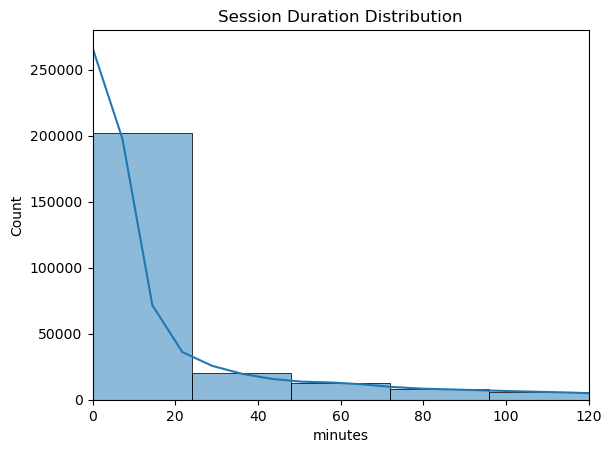

In [28]:
sns.histplot(
    session_metrics["minutes"],
    bins=60, 
    kde=True
)
plt.xlim(0,120)
plt.title("Session Duration Distribution")
plt.show()

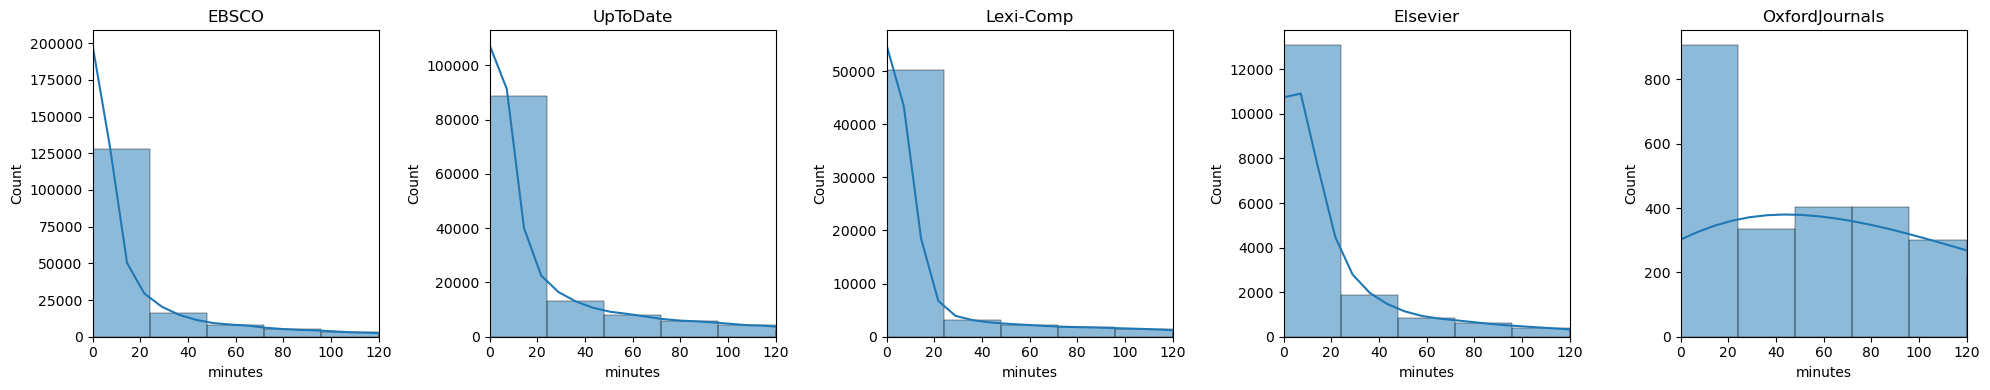

In [29]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

resources = [
    'EBSCO',
    'UpToDate',
    'Lexi-Comp', 
    'Elsevier',
    'OxfordJournals'
]

for ax, resource in zip(axes, resources):
    sns.histplot(
        df[df['host_name'] == resource]['minutes'],
        bins=60,
        kde=True,
        ax=ax
    )
    ax.set_xlim(0, 120)
    ax.set_title(resource)

plt.tight_layout()
plt.show()

---

### Usage by Time Period

> How does usage vary through the year, days of the week, or hours of the day?

#### Breakdown by Month, Day, and Hour

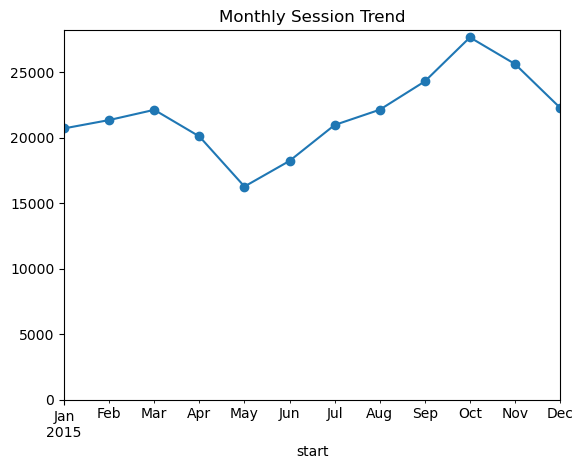

In [34]:
session_metrics.groupby(
    session_metrics["start"].dt.to_period("M")
)["session_id"].nunique().plot(marker="o")
plt.ylim(0, None)
plt.title("Monthly Session Trend")
plt.show()

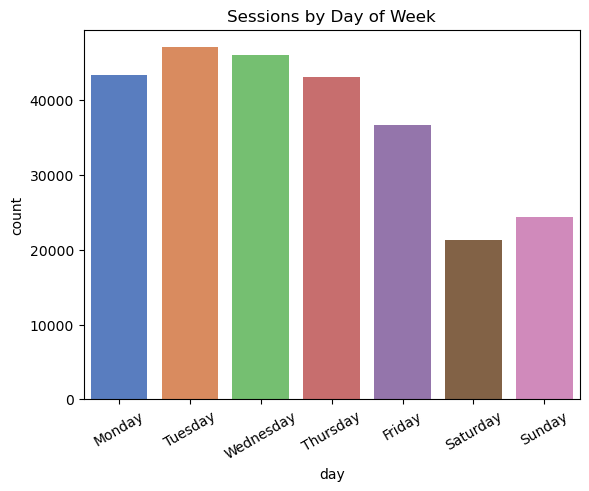

In [35]:
sns.countplot(
    data=session_metrics, x="day", hue='day', palette='muted', legend=False
)
plt.title("Sessions by Day of Week")
plt.xticks(rotation=30)
plt.show()

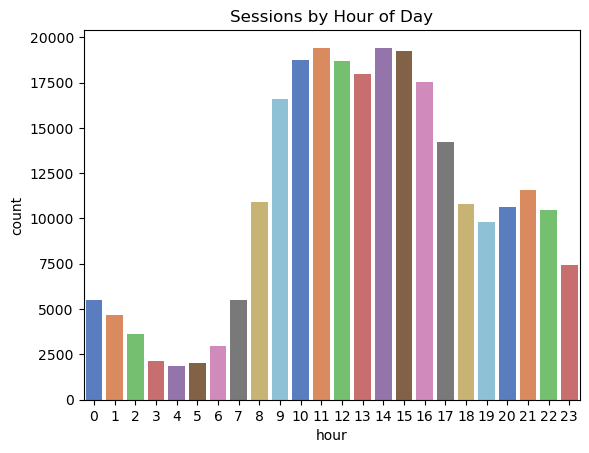

In [36]:
sns.countplot(
    data=session_metrics, x="hour", hue='hour', palette='muted', legend=False
)
plt.title("Sessions by Hour of Day")
plt.show()

#### Daily Usage by Host (Row Counts)

In [38]:
daily_usage = (
    df.groupby([
        df["start"].dt.date,
        "host_name"
    ])
    .size()
    .reset_index(name="rows")
)

In [39]:
top_hosts = (
    df["host_name"]
      .value_counts()
      .head(5)
      .index
)

plot_df = daily_usage[daily_usage["host_name"].isin(top_hosts)]

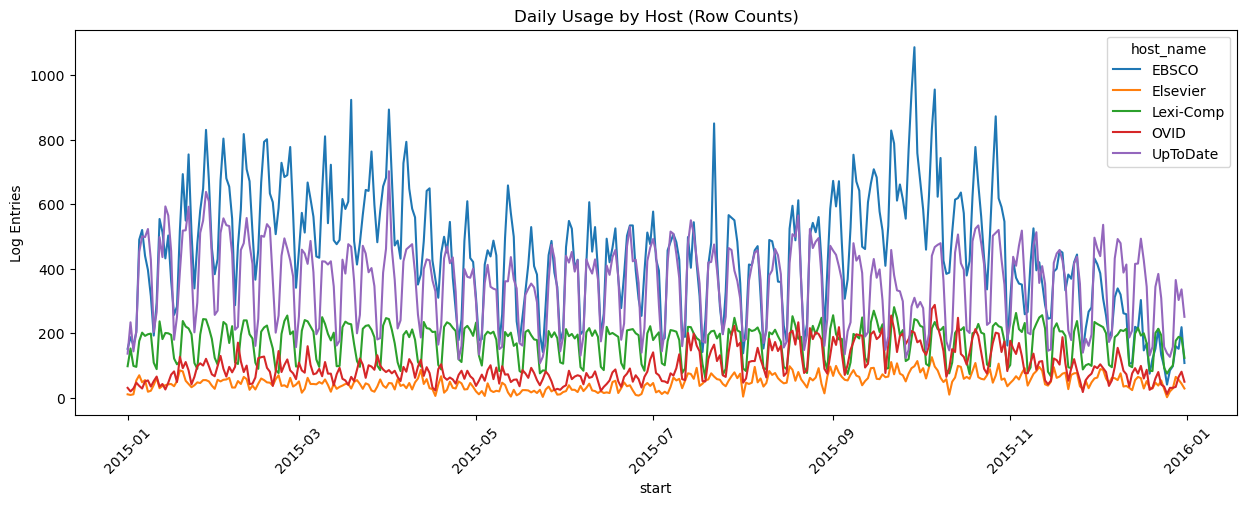

In [40]:
plt.figure(figsize=(15, 5))
sns.lineplot(
    data=plot_df,
    x="start",
    y="rows",
    hue="host_name"
)
plt.title("Daily Usage by Host (Row Counts)")
plt.ylabel("Log Entries")
plt.xticks(rotation=45)
plt.show()

---

### Usage by Location

> Where are users when they use the online library?

#### On-Campus vs Authenticated (Off-Campus) Access

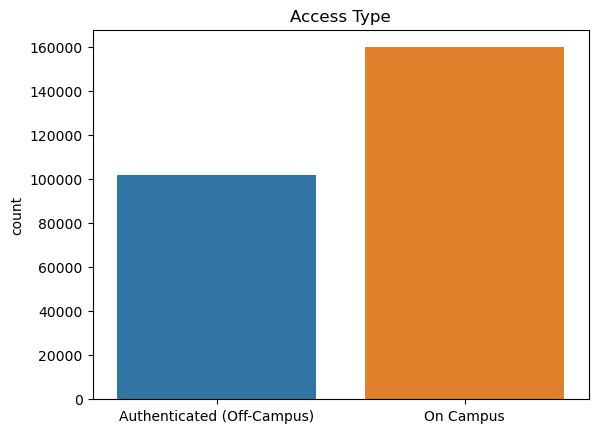

In [45]:
access_type = np.where(
    session_metrics["sha_username"] == "auto",
    "On Campus",
    "Authenticated (Off-Campus)"
)

sns.countplot(x=access_type, hue=access_type)
plt.title("Access Type")
plt.show()

#### Usage by Building

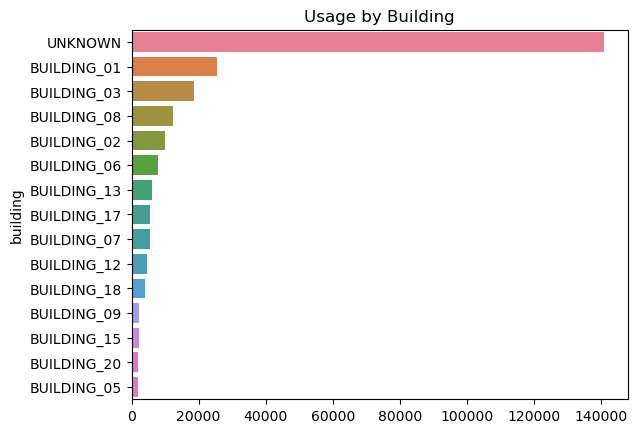

In [47]:
building = (
    session_metrics["building"]
      .value_counts()
      .head(15)
)

sns.barplot(
    x=building.values,
    y=building.index, 
    hue=building.index
)
plt.title("Usage by Building")
plt.show()

> Building attribution could not be mapped for a subset of sessions due to missing or incomplete VLAN-to-location mapping data. This is reflected in the presence of `UNKNOWN` values in the building field.

##### Exclude `UNKNOWN` Building for Better Visualization

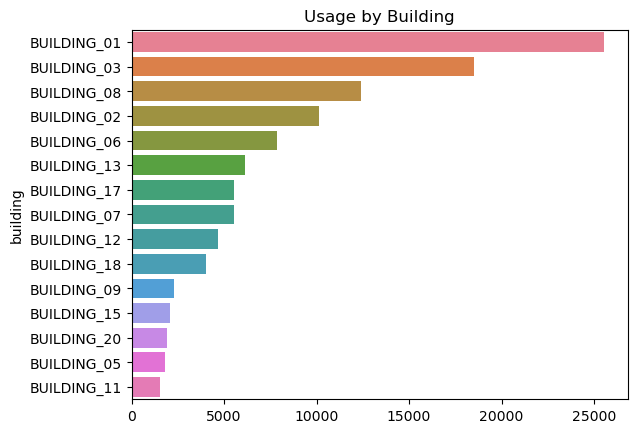

In [50]:
building = (
    session_metrics[session_metrics['building']!='UNKNOWN']["building"]
      .value_counts()
      .head(15)
)

sns.barplot(
    x=building.values,
    y=building.index, 
    hue=building.index
)
plt.title("Usage by Building")
plt.show()

---

### Usage by User Segmentation

> Which groups of users use the library and what resources do those groups use?

#### Affiliation Breakdown

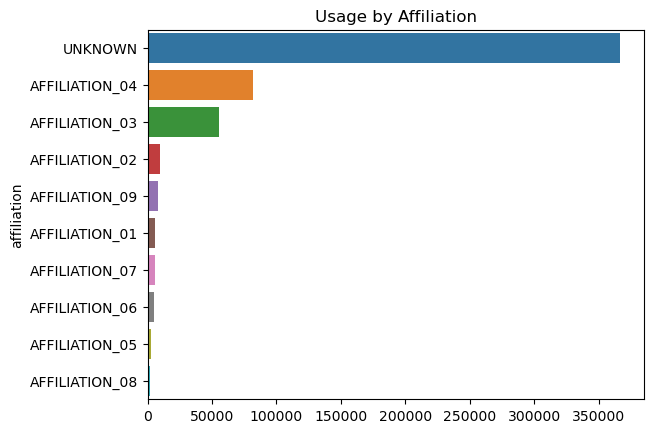

In [55]:
affiliation = (
    df["affiliation"]
      .value_counts()
      .head(10)
)

sns.barplot(
    x=affiliation.values,
    y=affiliation.index, 
    hue=affiliation.index
)
plt.title("Usage by Affiliation")
plt.show()

#### Role Breakdown

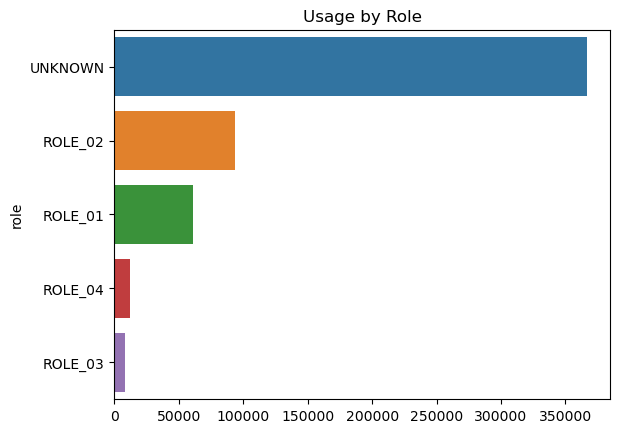

In [57]:
role = df["role"].value_counts()

sns.barplot(
    x=role.values,
    y=role.index, 
    hue=role.index
)
plt.title("Usage by Role")
plt.show()

> A substantial portion of authenticated users could not be mapped to affiliation or role attributes during LDAP resolution, either due to missing directory entries or incomplete institutional records. These cases are recorded as `UNKNOWN` in the final dataset.

#### Heatmap of Resource Usage by Affiliation

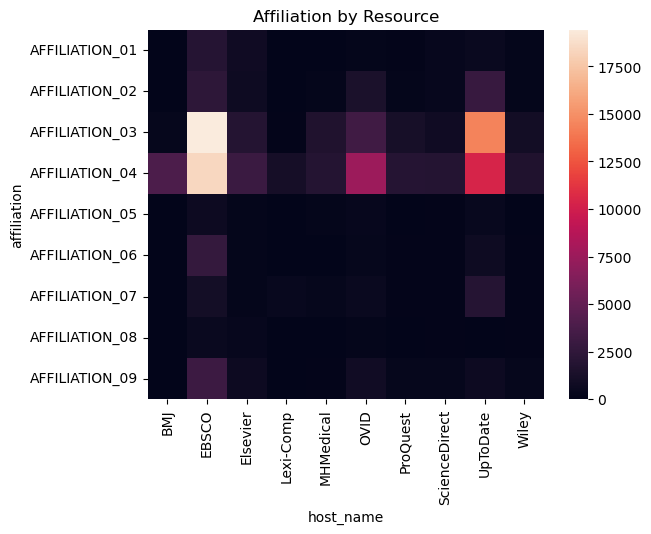

In [60]:
top_resources = (
    df["host_name"]
      .value_counts()
      .head(10)
      .index
)

base = df[
    (df["host_name"].isin(top_resources)) &
    (df["affiliation"] != "UNKNOWN")
]

heat = pd.crosstab(
    base["affiliation"],
    base["host_name"]
)

sns.heatmap(heat)
plt.title("Affiliation by Resource")
plt.show()